In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [2]:
pd.set_option('display.max_columns',None)
url = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/pre_ml_df.csv'

df = pd.read_csv(url)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')

## Encoding de categóricas

Como el objetivo es que estos datos entren a un modelo de Machine Learning, le hacemos un encoding a las variables categóricas.

Para eso exploramos un poco esas variables. Sin embargo, para análisis exploratorio multivariable usaremos el df que acabamos de guardar, ya que tiene estas variables no encodeadas y eso nos va a facilitar el análisis para tal caso.

Para el nivel del torneo podemos hacer un OrdinalEncoder tranquilamente

In [3]:
df['Series'].value_counts()

,count
Series,
Masters 1000,5884
Grand Slam,5459
ATP500,3954
ATP250,764


In [4]:
from sklearn.preprocessing import OrdinalEncoder # Ordinal Encoder -> con valores de 0 a n cantidad de variables

oe = OrdinalEncoder(categories=[['ATP250', 'ATP500', 'Masters 1000', 'Grand Slam']])
series_oe = oe.fit_transform(df[['Series']])
series_oe = pd.DataFrame(series_oe, columns=['series_level_oe'])
df = pd.concat([df, series_oe], axis=1)

Para Round armamos varias One Hot, porque tenemos ['1st Round', '2nd Round', 'Quarterfinals', 'Semifinals', 'The Final', '3rd Round', '4th Round'] y no sirve hacer un solo OneHot o un LabelEncoder ni otro.

Entonces encodeamos las instancias que son mas importantes: si es o no una final, si es o no una semifinal (donde puede llegar alguno que hizo un batacazo y eso puede influenciar) y si es o no 1st round

In [5]:
df['Round'].value_counts()

,count
Round,
1st Round,7252
2nd Round,4541
3rd Round,1768
Quarterfinals,1096
4th Round,583
Semifinals,548
The Final,273


In [6]:
round_order = {
    '1st Round': 1, '2nd Round': 2, '3rd Round': 3,
    '4th Round': 4, 'Quarterfinals': 5, 'Semifinals': 6, 'The Final': 7
}

df['round_encoded'] = df['Round'].map(round_order)

"Best of" es numerica pero categorica. Le hacemos One Hot

In [7]:
df['Best of'].value_counts()

,count
Best of,
3.0,10612
5.0,5449


In [8]:
df['is_best_of_5'] = (df['Best of'] == 5).astype(int)

Para Surface = ['Hard', 'Clay', 'Grass'] usamos FrequencyEncoder

In [9]:
df['Surface'].value_counts(normalize=True)

,proportion
Surface,
Hard,0.608617
Clay,0.293008
Grass,0.098375


In [10]:
surface_fe = df['Surface'].value_counts(normalize=True) # Generamos un pd.Series con la proporcion de cada valor unicos
df['surface_fe'] = df['Surface'].map(surface_fe)  # Armamos una variable donde cada valor recibe la frecuencia de aparicion de ese valor unico

Para Court = ['Outdoor', 'Indoor'] usamos OneHotEncoder

In [11]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')
court_encoded = ohe.fit_transform(df[['Court']])
court_encoded = pd.DataFrame(court_encoded, columns=ohe.get_feature_names_out()).rename(columns={'Court_Outdoor':'is_outdoor'})
df = pd.concat([df, court_encoded], axis=1)

Volvemos a guardar el df

In [12]:
columns_drop = ['Series', 'Court', 'Surface', 'Round', 'Best of']

In [13]:
df = df.drop(columns=columns_drop)

## Sigue preparación para ML

In [14]:
weather_cols = ['temperature_2m_mean',
       'apparent_temperature_mean', 'precipitation_sum', 'rain_sum',
       'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_gusts_10m_mean',
       'wind_speed_10m_mean', 'relative_humidity_2m_mean',
       'relative_humidity_2m_max', 'relative_humidity_2m_min',
       'soil_temperature_0_to_100cm_mean', 'soil_moisture_0_to_100cm_mean',
       'wind_gusts_10m_min', 'wind_speed_10m_min']

In [15]:
for col in weather_cols:
    df[col] = df[col]*df['is_outdoor']

In [16]:
# Consenso de probabilidad entre casas (A qué tan de acuerdo están)
df['prob_consensus_A'] = (df['B365ProbA'] + df['ProbAvgA'] + df['ProbMaxA']) / 3

# Dispersión entre casas → incertidumbre de mercado más fina
df['bookmaker_std_A'] = df[['B365ProbA', 'ProbAvgA', 'ProbMaxA']].std(axis=1)

# Ratio de probabilidades (más informativo que la diferencia en extremos)
df['prob_ratio_B365'] = df['B365ProbA'] / df['B365ProbB']

# "Desacuerdo" entre B365 y el promedio del mercado
df['b365_vs_market'] = df['B365ProbA'] - df['ProbAvgA']

# Ratio en lugar de diferencia (rankDiff de 10 no es igual si es 1vs11 que 100vs110)
df['rankRatio'] = df['rankA'] / df['rankB']
df['log_rankDiff'] = np.log(df['rankA'] + 1) - np.log(df['rankB'] + 1)

# Nivel del partido (¿es un partido entre top players?)
df['rank_sum'] = df['rankA'] + df['rankB']
df['ptsRatio'] = df['PtsA'] / (df['PtsA'] + df['PtsB'])

# ¿Está mejorando o decayendo en los últimos partidos?
df['momentum_A'] = df['winrate_5_A'] - df['winrate_10_A']
df['momentum_B'] = df['winrate_5_B'] - df['winrate_10_B']
df['diff_momentum']  = df['momentum_A'] - df['momentum_B']

# Intensidad de actividad reciente
df['sets_per_day_30d_A'] = df['sets_30d_A'] / (df['dias_ultimo_partido_A'] + 1)
df['sets_per_day_30d_B'] = df['sets_30d_B'] / (df['dias_ultimo_partido_B'] + 1)
df['diff_sets_per_day'] = df['sets_per_day_30d_A'] - df['sets_per_day_30d_B']

# En best-of-5, el ranking y la forma pesan más
df['bo5_rank_diff']     = df['is_best_of_5'] * df['rankDiff']
df['bo5_momentum_diff'] = df['is_best_of_5'] * df['diff_momentum']

In [17]:
new_df = df.drop(columns=['Location', 'Fecha', 'playerA', 'playerB',
                          'A1', 'B1', 'A2', 'B2', 'A3', 'B3', 'A4', 'B4', 'A5',
                          'B5', 'setsA', 'setsB', 'setsPartido'])

In [18]:
df_no_nulls = new_df.dropna()

In [19]:
X = df_no_nulls.drop(columns=['target'])
y = df_no_nulls['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

## Modelo 0: baseline

In [20]:
# Nivel 1 — Mayoría simple (lower bound absoluto)
majority_class = y_train.mode()[0]
baseline_majority = np.full(len(y_test), majority_class)

# Nivel 2 — Tu baseline de ranking (naive sports knowledge)
y_baseline_rank = (X_test['rankA'] < X_test['rankB']).astype(int)

# Nivel 3 — Baseline de odds (upper bound)
y_baseline_odds = (X_test['B365ProbA'] > 0.5).astype(int)

for name, pred in [("Mayoría", baseline_majority),
                   ("Ranking", y_baseline_rank),
                   ("Odds B365", y_baseline_odds)]:
    print(f"{name}: {accuracy_score(y_test, pred):.3f}")

Mayoría: 0.513
Ranking: 0.673
Odds B365: 0.716


Vemos confusion matrix para cada caso

In [21]:
print('Matriz de confusion para baseline mayoría:')
print(confusion_matrix(y_test, baseline_majority))

print('Matriz de confusion para baseline ranking:')
print(confusion_matrix(y_test, y_baseline_rank))

print('Matriz de confusion para baseline odds:')
print(confusion_matrix(y_test, y_baseline_odds))

Matriz de confusion para baseline mayoría:
[[1593    0]
 [1511    0]]
Matriz de confusion para baseline ranking:
[[1063  530]
 [ 485 1026]]
Matriz de confusion para baseline odds:
[[1143  450]
 [ 432 1079]]


## Modelo 1: Logistic Regression

In [24]:
logreg = LogisticRegression(fit_intercept=False,random_state=42)
logreg.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(fit_intercept=False, random_state=42)

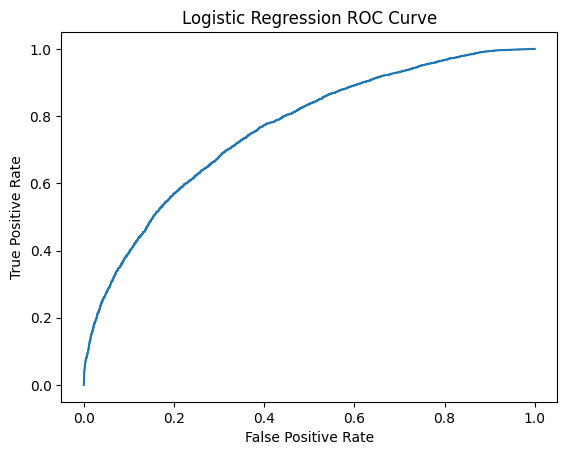

In [25]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, logreg.predict_proba(X_train)[:, 1])
#plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.show()

In [26]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_train, logreg.predict_proba(X_train)[:, 1]))

0.7608315120683586


In [27]:
y_logreg = logreg.predict(X_test)

In [28]:
print('Matriz de confusion para Logistic Regression:')
print(confusion_matrix(y_test, y_logreg))

print('Reporte de clasificación para Logistic Regression:')
print(classification_report(y_test, y_logreg))

Matriz de confusion para Logistic Regression:
[[1136  457]
 [ 474 1037]]
Reporte de clasificación para Logistic Regression:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71      1593
           1       0.69      0.69      0.69      1511

    accuracy                           0.70      3104
   macro avg       0.70      0.70      0.70      3104
weighted avg       0.70      0.70      0.70      3104



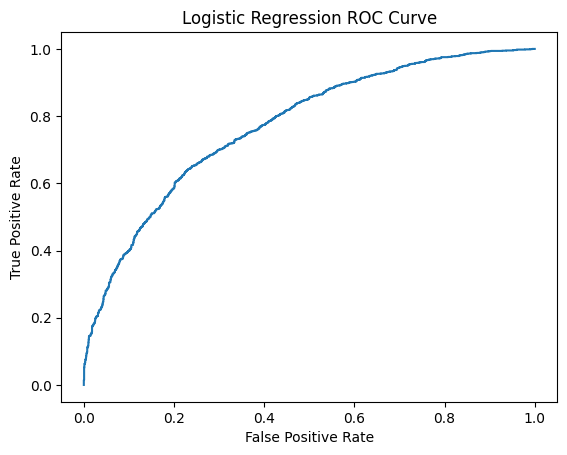

In [29]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:, 1])
#plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.show()

In [30]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1]))

0.772102302304548


## Modelo 2: Logistic Regression Optimized

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid = {
    'logistic__C'          : np.logspace(-3, 3, 20),  # Regularización
    'logistic__penalty'    : ['l1', 'l2'],
    'logistic__solver'     : ['liblinear'],
}

pipeline = Pipeline([
    ('scaler',   StandardScaler()),
    ('logistic', LogisticRegression(max_iter=1000, random_state=42))
])

search_lr = RandomizedSearchCV(
    estimator           = pipeline,
    param_distributions = param_grid,
    n_iter              = 30,
    cv                  = 5,
    scoring             = 'roc_auc',
    n_jobs              = 1,
    random_state        = 42,
    verbose             = 2
)

search_lr.fit(X_train, y_train)

print(f"Mejores parámetros: {search_lr.best_params_}")
print(f"Mejor ROC-AUC: {search_lr.best_score_:.4f}")

modelo_lr = search_lr.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END logistic__C=0.6951927961775606, logistic__penalty=l2, logistic__solver=liblinear; total time=   1.1s
[CV] END logistic__C=0.6951927961775606, logistic__penalty=l2, logistic__solver=liblinear; total time=   0.7s
[CV] END logistic__C=0.6951927961775606, logistic__penalty=l2, logistic__solver=liblinear; total time=   0.7s
[CV] END logistic__C=0.6951927961775606, logistic__penalty=l2, logistic__solver=liblinear; total time=   0.6s
[CV] END logistic__C=0.6951927961775606, logistic__penalty=l2, logistic__solver=liblinear; total time=   1.1s
[CV] END logistic__C=0.3359818286283781, logistic__penalty=l1, logistic__solver=liblinear; total time=   2.4s
[CV] END logistic__C=0.3359818286283781, logistic__penalty=l1, logistic__solver=liblinear; total time=   0.7s
[CV] END logistic__C=0.3359818286283781, logistic__penalty=l1, logistic__solver=liblinear; total time=   0.7s
[CV] END logistic__C=0.3359818286283781, logistic__penalty

In [ ]:
y_pred_lr      = modelo_lr.predict(X_test)
y_pred_lr_prob = modelo_lr.predict_proba(X_test)[:, 1]

NameError: name 'modelo_lr' is not defined

## Modelo 3: DecisionTree

In [31]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(max_depth=50, min_samples_leaf=10, max_leaf_nodes=100, random_state=42) # max_depth representa la profundidad del arbol de decision.
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=50, max_leaf_nodes=100, min_samples_leaf=10,
                       random_state=42)

In [ ]:
# from sklearn.tree import plot_tree
# plt.figure(figsize=(10, 8))

# plot_tree(tree_clf,
#           feature_names=X_train.columns,
#           class_names=['Gana B', 'Gana A'],
#           rounded=True,
#           filled=True)
# plt.show()

In [32]:
print('Profundidad del árbol:', tree_clf.get_depth())                    # Profundidad
print('Número de nodos terminales (hoja): ', tree_clf.get_n_leaves())    # Cantidad de nodos hoja

Profundidad del árbol: 16
Número de nodos terminales (hoja):  100


In [33]:
y_tree_clf = tree_clf.predict(X_test)

In [34]:
print(confusion_matrix(y_test, tree_clf.predict(X_test)))

[[1070  523]
 [ 420 1091]]


## Modelo 4: RandomForest

In [39]:
rnd_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,          # limitar profundidad, el más importante
    min_samples_leaf=30,  # cada hoja necesita al menos 30 partidos
    min_samples_split=50, # para splitear un nodo necesita 50 muestras
    max_features='sqrt',  # ya lo hace por default, pero explicitarlo
    random_state=42
)
rnd_clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=30, min_samples_split=50,
                       n_estimators=200, random_state=42)

In [40]:
y_pred_rf_test = rnd_clf.predict(X_test)

In [42]:
print('Matriz de confusión de datos de test:')
print(confusion_matrix(y_test, y_pred_rf_test))

print('Classification report de datos de test:')
print(classification_report(y_test, y_pred_rf_test))

Matriz de confusión de datos de test:
[[1122  471]
 [ 416 1095]]
Classification report de datos de test:
              precision    recall  f1-score   support

           0       0.73      0.70      0.72      1593
           1       0.70      0.72      0.71      1511

    accuracy                           0.71      3104
   macro avg       0.71      0.71      0.71      3104
weighted avg       0.71      0.71      0.71      3104



In [41]:
# Diagnóstico rápido
print("Train accuracy:", rnd_clf.score(X_train, y_train))
print("Test accuracy: ", rnd_clf.score(X_test, y_test))
print("Odds baseline: ", accuracy_score(y_test, (X_test['B365ProbA'] > 0.5).astype(int)))

Train accuracy: 0.7172091524331292
Test accuracy:  0.7142396907216495
Odds baseline:  0.7158505154639175


In [43]:
from sklearn.calibration import calibration_curve

# Probabilidades de tu modelo
proba = rnd_clf.predict_proba(X_test)[:, 1]

# ¿Cuándo tu modelo dice 0.7 y las odds dicen 0.5, quién tiene razón?
df_test = X_test.copy()
df_test['y_true'] = y_test.values
df_test['proba_modelo'] = proba
df_test['proba_odds'] = df_test['B365ProbA']

# Partidos donde tu modelo y las odds difieren más
df_test['desacuerdo'] = (df_test['proba_modelo'] - df_test['proba_odds']).abs()
df_test.sort_values('desacuerdo', ascending=False).head(20)

,rankA,rankB,PtsA,PtsB,B365A,B365B,MaxA,MaxB,AvgA,AvgB,B365BookmakersMargin,B365ProbA,B365ProbB,ProbAvgA,ProbAvgB,ProbMaxA,ProbMaxB,market_uncertainty,OddsDiffB365,OddsDiffAvg,OddsDiffMax,AvgOddsDiff,logit_oddsA,logit_oddsB,rankDiff,ptsDiff,winrate_5_A,winrate_10_A,wins_before_A,win_pct_before_A,sets_5d_A,sets_30d_A,partidos_365d_A,dias_ultimo_partido_A,racha_victorias_A,winrate_5_B,winrate_10_B,wins_before_B,win_pct_before_B,sets_5d_B,sets_30d_B,partidos_365d_B,dias_ultimo_partido_B,racha_victorias_B,diff_winrate_5,diff_winrate_10,diff_win_pct_before,diff_sets_5d,diff_sets_30d,diff_dias_ultimo_partido,diff_partidos_365d,h2h_matches_previous,temperature_2m_mean,apparent_temperature_mean,precipitation_sum,rain_sum,wind_speed_10m_max,wind_gusts_10m_max,wind_gusts_10m_mean,wind_speed_10m_mean,relative_humidity_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,soil_temperature_0_to_100cm_mean,soil_moisture_0_to_100cm_mean,wind_gusts_10m_min,wind_speed_10m_min,series_level_oe,round_encoded,is_best_of_5,surface_fe,is_outdoor,prob_consensus_A,bookmaker_std_A,prob_ratio_B365,b365_vs_market,rankRatio,log_rankDiff,rank_sum,ptsRatio,momentum_A,momentum_B,diff_momentum,sets_per_day_30d_A,sets_per_day_30d_B,diff_sets_per_day,bo5_rank_diff,bo5_momentum_diff,y_true,proba_modelo,proba_odds,desacuerdo
2530,2.0,7.0,8915.0,3175.0,1.25,4.33,4.36,1.30,3.97,1.26,0.030947,0.775986,0.224014,0.240918,0.759082,0.229682,0.770318,0.259082,-3.08,2.71,3.06,-0.518164,-1.147654,1.147654,-5.0,5740.0,1.0,0.9,89.0,0.824074,8.0,20.0,61,2.0,6,1.000000,0.900000,52.0,0.732394,9.0,23.0,45,2.0,6,0.000000,0.000000,0.091680,-1.0,-3.0,0.0,16,3,17.520500,15.761944,0.200000,0.200000,27.059933,50.760000,41.324993,21.809044,81.931390,91.111336,63.508724,16.243145,0.334862,32.760002,17.238699,3.0,7,1,0.098375,1.0,0.415528,0.312216,3.464000,0.535068,0.285714,-0.980829,9.0,0.737386,0.1,0.1,0.0,6.666667,7.666667,-1.000000,-5.0,0.0,1,0.312112,0.775986,0.463874
5804,7.0,19.0,4445.0,1755.0,1.57,2.37,1.67,2.63,1.59,2.45,0.058884,0.601523,0.398477,0.606436,0.393564,0.611628,0.388372,0.106436,-0.80,-0.86,-0.96,0.212871,0.432354,-0.432354,-12.0,2690.0,0.8,0.8,116.0,0.698795,11.0,24.0,51,2.0,4,0.800000,0.700000,132.0,0.721311,8.0,15.0,35,2.0,4,0.000000,0.100000,-0.022516,3.0,9.0,0.0,16,5,26.337502,30.778902,0.000000,0.000000,18.919704,34.560000,18.555000,9.439261,84.730110,97.634600,66.027450,24.528397,0.328982,5.400000,2.189795,3.0,5,1,0.608617,1.0,0.606529,0.005053,1.509554,-0.004913,0.368421,-0.916291,26.0,0.716935,0.0,0.1,-0.1,8.000000,5.000000,3.000000,-12.0,-0.1,0,0.486765,0.601523,0.114758
11422,5.0,15.0,3660.0,2350.0,1.44,2.75,1.56,2.75,1.49,2.59,0.058081,0.656325,0.343675,0.634804,0.365196,0.638051,0.361949,0.134804,-1.31,-1.10,-1.19,0.269608,0.552882,-0.552882,-10.0,1310.0,0.8,0.6,100.0,0.549451,5.0,13.0,46,1.0,3,0.600000,0.700000,81.0,0.503106,4.0,9.0,45,1.0,2,0.200000,-0.100000,0.046345,1.0,4.0,0.0,1,5,25.804335,29.398420,1.200000,1.200000,14.578888,45.000000,25.620000,7.453468,76.743550,95.573570,58.579780,26.465483,0.321012,9.000000,2.099143,1.0,5,0,0.608617,1.0,0.643060,0.011602,1.909722,0.021521,0.333333,-0.980829,20.0,0.608985,0.2,-0.1,0.3,6.500000,4.500000,2.000000,-0.0,0.0,1,0.547252,0.656325,0.109072
4457,64.0,11.0,792.0,2650.0,1.90,1.80,1.91,2.10,1.85,1.94,0.081871,0.486486,0.513514,0.511873,0.488127,0.523691,0.476309,0.011873,0.10,-0.09,-0.19,0.023747,0.047502,-0.047502,53.0,-1858.0,0.6,0.6,21.0,0.466667,0.0,0.0,21,54.0,0,0.400000,0.600000,36.0,0.590164,0.0,4.0,44,14.0,0,0.200000,0.000000,-0.123497,0.0,-4.0,40.0,-23,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1,0,0.608617,0.0,0.507350,0.019010,0.947368,-0.025387,5.818182,1.689481,75.0,0.230099,0.0,-0.2,0.2,0.000000,0.266667,-0.266667,0.0,0.0,0,0.591910,0.486486,0.105423
13271,65.0,40.0,856.0,1092.0,7.00,1.10,3.90,1.33,3.72,1.29,0.051948,0.135802,0.864198,0.257485,0.742515,0.254302,0.745698,0.242515,5.90,2.43,2.

In [44]:
importances = rnd_clf.feature_importances_
features = X.columns
feature_importances = pd.DataFrame({'feature': features, 'importance': importances}).sort_values('importance', ascending=False)

In [45]:
pd.concat([feature_importances.head(20).reset_index(drop=True).rename(columns={'feature': 'top_20'}), feature_importances.tail(20).reset_index(drop=True).rename(columns={'feature': 'bottom_20'})], axis=1)

,top_20,importance,bottom_20,importance
0,AvgOddsDiff,0.079654,diff_momentum,0.001033
1,ProbAvgA,0.071086,diff_sets_30d,0.001021
2,ProbMaxA,0.065017,precipitation_sum,0.000937
3,ProbAvgB,0.062287,sets_5d_A,0.000769
4,ProbMaxB,0.061825,bo5_rank_diff,0.000758
5,MaxA,0.057023,diff_winrate_5,0.000673
6,logit_oddsB,0.049769,winrate_5_B,0.000660
7,logit_oddsA,0.049460,momentum_A,0.000600
8,prob_consensus_A,0.043241,racha_victorias_B,0.000600
9,OddsDiffMax,0.041013,winrate_5_A,0.000571


## Modelo 5: RandomForest Optimo

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators'      : [100, 200, 500],
    'max_depth'         : [5, 10, 20, 25],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2'],
}

search = RandomizedSearchCV(
    estimator   = RandomForestClassifier(random_state=42),
    param_distributions = param_grid,
    n_iter      = 50,        # Prueba 50 combinaciones aleatorias
    cv          = 5,         # 5-fold cross validation
    scoring     = 'roc_auc', # Métrica a optimizar
    n_jobs      = -1,        # Usa todos los cores
    random_state= 42
)

search.fit(X_train, y_train)

print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor ROC-AUC: {search.best_score_:.4f}")

modelo_optimo = search.best_estimator_

Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5}
Mejor ROC-AUC: 0.7788


In [ ]:
y_best_pred = modelo_optimo.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_best_pred))

[[1128  465]
 [ 416 1095]]


In [ ]:
print(classification_report(y_test, y_best_pred))

              precision    recall  f1-score   support

           0       0.73      0.71      0.72      1593
           1       0.70      0.72      0.71      1511

    accuracy                           0.72      3104
   macro avg       0.72      0.72      0.72      3104
weighted avg       0.72      0.72      0.72      3104



## Modelo 6: LGBM

In [ ]:
from lightgbm import LGBMClassifier

modelo = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42)
modelo.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 6169, number of negative: 6243
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032646 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12497
[LightGBM] [Info] Number of data points in the train set: 12412, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497019 -> initscore=-0.011924
[LightGBM] [Info] Start training from score -0.011924


LGBMClassifier(learning_rate=0.05, n_estimators=500, random_state=42)

In [ ]:
new_y_pred = modelo.predict(X_test)

In [ ]:
new_y_pred

array([0, 1, 0, ..., 0, 1, 0])

In [ ]:
confusion_matrix(y_test, new_y_pred)

array([[1105,  488],
       [ 465, 1046]])

## Modelo 7: xG

In [55]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    max_depth=3,          # menos profundidad
    n_estimators=500,
    learning_rate=0.01,   # más lento pero mejor generalización
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=30,  # equivalente a min_samples_leaf
    random_state=42
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=30, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [56]:
y_xgboost = xgb.predict(X_test)

In [57]:
print(accuracy_score(y_test, y_xgboost))

0.7139175257731959


## Eval Resultados

In [48]:
# Unimos todo en un solo df para trabajar cómodo
resultados = X_test[['B365A', 'B365B']].copy()
resultados['y_real']      = y_test.values
resultados['y_pred']      = rnd_clf.predict(X_test)  # el 0/1 que devuelve el modelo
resultados['prob_mercado_A'] = X_test['B365ProbA']

In [49]:
# Cuota a cobrar según la predicción
resultados['cuota_apostada'] = resultados.apply(
    lambda row: row['B365A'] if row['y_pred'] == 1 else row['B365B'], axis=1
)

# Ganó la apuesta si la predicción coincide con el resultado real
resultados['acierto'] = resultados['y_pred'] == resultados['y_real']

# Ganancia por partido (apuesta de 1 unidad)
resultados['ganancia'] = resultados.apply(
    lambda row: row['cuota_apostada'] - 1 if row['acierto'] else -1, axis=1
)

# Resumen
n_apuestas = len(resultados)
ganancia_total = resultados['ganancia'].sum()
roi = ganancia_total / n_apuestas * 100

print(f"Apuestas realizadas: {n_apuestas}")
print(f"Aciertos: {resultados['acierto'].sum()} ({resultados['acierto'].mean()*100:.1f}%)")
print(f"Ganancia total: {ganancia_total:.2f} unidades")
print(f"ROI: {roi:.2f}%")

Apuestas realizadas: 3104
Aciertos: 2217 (71.4%)
Ganancia total: -109.40 unidades
ROI: -3.52%


# Parte 2: espejado

In [60]:
new_df.columns

Index(['rankA', 'rankB', 'PtsA', 'PtsB', 'B365A', 'B365B', 'MaxA', 'MaxB',
       'AvgA', 'AvgB', 'target', 'B365BookmakersMargin', 'B365ProbA',
       'B365ProbB', 'ProbAvgA', 'ProbAvgB', 'ProbMaxA', 'ProbMaxB',
       'market_uncertainty', 'OddsDiffB365', 'OddsDiffAvg', 'OddsDiffMax',
       'AvgOddsDiff', 'logit_oddsA', 'logit_oddsB', 'rankDiff', 'ptsDiff',
       'winrate_5_A', 'winrate_10_A', 'wins_before_A', 'win_pct_before_A',
       'sets_5d_A', 'sets_30d_A', 'partidos_365d_A', 'dias_ultimo_partido_A',
       'racha_victorias_A', 'winrate_5_B', 'winrate_10_B', 'wins_before_B',
       'win_pct_before_B', 'sets_5d_B', 'sets_30d_B', 'partidos_365d_B',
       'dias_ultimo_partido_B', 'racha_victorias_B', 'diff_winrate_5',
       'diff_winrate_10', 'diff_win_pct_before', 'diff_sets_5d',
       'diff_sets_30d', 'diff_dias_ultimo_partido', 'diff_partidos_365d',
       'h2h_matches_previous', 'temperature_2m_mean',
       'apparent_temperature_mean', 'precipitation_sum', 'rain_sum',
  

In [61]:
def mirror_dataset(df):
    df_mirror = df.copy()

    # 1. Pares A/B a swappear directamente
    swap_pairs = [
        ('rankA', 'rankB'),
        ('PtsA', 'PtsB'),
        ('B365A', 'B365B'),
        ('MaxA', 'MaxB'),
        ('AvgA', 'AvgB'),
        ('B365ProbA', 'B365ProbB'),
        ('ProbAvgA', 'ProbAvgB'),
        ('ProbMaxA', 'ProbMaxB'),
        ('logit_oddsA', 'logit_oddsB'),
        ('winrate_5_A', 'winrate_5_B'),
        ('winrate_10_A', 'winrate_10_B'),
        ('wins_before_A', 'wins_before_B'),
        ('win_pct_before_A', 'win_pct_before_B'),
        ('sets_5d_A', 'sets_5d_B'),
        ('sets_30d_A', 'sets_30d_B'),
        ('partidos_365d_A', 'partidos_365d_B'),
        ('dias_ultimo_partido_A', 'dias_ultimo_partido_B'),
        ('racha_victorias_A', 'racha_victorias_B'),
        ('prob_consensus_A', 'prob_consensus_B'),  # si existe
        ('momentum_A', 'momentum_B'),
        ('sets_per_day_30d_A', 'sets_per_day_30d_B'),
    ]

    for col_a, col_b in swap_pairs:
        if col_a in df.columns and col_b in df.columns:
            df_mirror[col_a] = df[col_b]
            df_mirror[col_b] = df[col_a]

    # 2. Columnas calculadas solo para A que necesitan recalcularse
    # (bookmaker_std_A, b365_vs_market -> pasan a ser de B, pero como el partido
    # se espeja, simplemente se invierten con A)
    if 'bookmaker_std_A' in df.columns:
        # Era std de las probs de A, ahora es std de las probs de B (que pasaron a ser A)
        # Ya está cubierto porque swappeamos B365ProbA/B, ProbAvgA/B, ProbMaxA/B
        # Recalcular es lo más limpio:
        df_mirror['bookmaker_std_A'] = df_mirror[['B365ProbA', 'ProbAvgA', 'ProbMaxA']].std(axis=1)

    if 'prob_consensus_A' in df.columns:
        df_mirror['prob_consensus_A'] = df_mirror[['B365ProbA', 'ProbAvgA', 'ProbMaxA']].mean(axis=1)

    if 'b365_vs_market' in df.columns:
        df_mirror['b365_vs_market'] = df_mirror['B365ProbA'] - df_mirror['ProbAvgA']

    if 'prob_ratio_B365' in df.columns:
        df_mirror['prob_ratio_B365'] = df_mirror['B365ProbA'] / df_mirror['B365ProbB']

    # 3. Diffs A-B → invertir signo
    diff_cols = [
        'OddsDiffB365', 'OddsDiffAvg', 'OddsDiffMax', 'AvgOddsDiff',
        'rankDiff', 'ptsDiff',
        'diff_winrate_5', 'diff_winrate_10', 'diff_win_pct_before',
        'diff_sets_5d', 'diff_sets_30d', 'diff_dias_ultimo_partido',
        'diff_partidos_365d', 'diff_momentum', 'diff_sets_per_day',
        'log_rankDiff',
    ]
    for col in diff_cols:
        if col in df.columns:
            df_mirror[col] = -df[col]

    # 4. Ratios que dependen del orden A/B → recalcular
    if 'rankRatio' in df.columns:
        df_mirror['rankRatio'] = df_mirror['rankA'] / df_mirror['rankB']

    if 'ptsRatio' in df.columns:
        df_mirror['ptsRatio'] = df_mirror['PtsA'] / (df_mirror['PtsA'] + df_mirror['PtsB'])

    # 5. Interacciones que dependen de diffs → recalcular
    if 'bo5_rank_diff' in df.columns:
        df_mirror['bo5_rank_diff'] = df_mirror['is_best_of_5'] * df_mirror['rankDiff']

    if 'bo5_momentum_diff' in df.columns:
        df_mirror['bo5_momentum_diff'] = df_mirror['is_best_of_5'] * df_mirror['diff_momentum']

    # 6. Columnas simétricas → no tocar
    # h2h_matches_previous, market_uncertainty, B365BookmakersMargin,
    # rank_sum, todas las de clima, series_level_oe, round_encoded,
    # is_best_of_5, surface_fe, is_outdoor

    # 7. Target invertido
    df_mirror['target'] = 1 - df['target']

    # 8. Combinar y mezclar
    df_full = pd.concat([df, df_mirror], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

    return df_full

In [71]:
df_sorted = df.copy().sort_values('Fecha')
df_sorted = df.drop(columns=['Location', 'Fecha', 'playerA', 'playerB',
                          'A1', 'B1', 'A2', 'B2', 'A3', 'B3', 'A4', 'B4', 'A5',
                          'B5', 'setsA', 'setsB', 'setsPartido']).dropna()
train = df_sorted.iloc[:int(len(df_sorted) * 0.8)]
test  = df_sorted.iloc[int(len(df_sorted) * 0.8):]

# Espejás solo el train, nunca el test
train_mirrored = mirror_dataset(train)

X_train = train_mirrored.drop('target', axis=1)
y_train = train_mirrored['target']
X_test = test.drop('target', axis=1)
y_test = test['target']

In [73]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score
import numpy as np

# Validación temporal (no mezcla fechas)
tscv = TimeSeriesSplit(n_splits=5)

# ── RANDOM FOREST ──────────────────────────────────────────
rf_params = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [4, 6, 8, 10],
    'min_samples_leaf':  [20, 30, 50],
    'min_samples_split': [40, 60, 100],
    'max_features':      ['sqrt', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=30,
    cv=tscv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

# ── XGBOOST ───────────────────────────────────────────────
xgb_params = {
    'n_estimators':    [200, 300, 500],
    'max_depth':       [3, 4],
    'learning_rate':   [0.01, 0.05, 0.1],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree':[0.7, 0.8, 1.0],
    'min_child_weight':[20, 30, 50],
    'gamma':           [0.1, 0.3],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=30,
    cv=tscv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

# ── COMPARACIÓN ───────────────────────────────────────────
odds_baseline = accuracy_score(y_test, (X_test['B365ProbA'] > 0.5).astype(int))

print(f"{'Modelo':<20} {'Train':>8} {'Test':>8}")
print("-" * 38)
for name, model in [("Random Forest", best_rf), ("XGBoost", best_xgb)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    print(f"{name:<20} {train_acc:>8.4f} {test_acc:>8.4f}")

print(f"{'Odds baseline':<20} {'---':>8} {odds_baseline:>8.4f}")

# ── MEJORES PARÁMETROS ────────────────────────────────────
print("\nMejores parámetros RF:", rf_search.best_params_)
print("Mejores parámetros XGB:", xgb_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


KeyboardInterrupt: 

In [75]:
tscv = TimeSeriesSplit(n_splits=3)  # 3 en lugar de 5

rf_params = {
    'n_estimators':      [100, 200],
    'max_depth':         [4, 6],       # sin None
    'min_samples_leaf':  [30, 50],
    'min_samples_split': [60, 100],
    'max_features':      ['sqrt'],
}

xgb_params = {
    'n_estimators':     [200, 300],
    'max_depth':        [3, 4],
    'learning_rate':    [0.01, 0.05],
    'subsample':        [0.8],
    'colsample_bytree': [0.8],
    'min_child_weight': [30, 50],
    'gamma':            [0.1],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=10,        # 10 en lugar de 30
    cv=tscv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=10,
    cv=tscv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [76]:
# ── COMPARACIÓN ───────────────────────────────────────────
odds_baseline = accuracy_score(y_test, (X_test['B365ProbA'] > 0.5).astype(int))

print(f"{'Modelo':<20} {'Train':>8} {'Test':>8}")
print("-" * 38)
for name, model in [("Random Forest", best_rf), ("XGBoost", best_xgb)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    print(f"{name:<20} {train_acc:>8.4f} {test_acc:>8.4f}")

print(f"{'Odds baseline':<20} {'---':>8} {odds_baseline:>8.4f}")

# ── MEJORES PARÁMETROS ────────────────────────────────────
print("\nMejores parámetros RF:", rf_search.best_params_)
print("Mejores parámetros XGB:", xgb_search.best_params_)

Modelo                  Train     Test
--------------------------------------
Random Forest          0.7119   0.6949
XGBoost                0.7121   0.6939
Odds baseline             ---   0.6943

Mejores parámetros RF: {'n_estimators': 100, 'min_samples_split': 60, 'min_samples_leaf': 30, 'max_features': 'sqrt', 'max_depth': 4}
Mejores parámetros XGB: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 30, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
